In [25]:
import os
import json
import torch
import random
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch_geometric.data import Dataset, Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from torch.nn import Dropout, BatchNorm1d
from torch.utils.data import random_split
from sklearn.model_selection import train_test_split

In [26]:
# Fix random seeds
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

In [27]:
# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cuda


In [64]:
from collections import Counter

TOP_K_APIS = 200  # only use top 100 api_methods
# Step 1: Scan top K API methods
api_counter = Counter()
root_dir = "Static_Features"
for family in os.listdir(root_dir):
    fam_path = os.path.join(root_dir, family)
    if not os.path.isdir(fam_path):
        continue
    for file in os.listdir(fam_path):
        if file.endswith(".json"):
            try:
                with open(os.path.join(fam_path, file)) as f:
                    js = json.load(f)
                api_counter.update(js.get("api_methods", []))
            except:
                continue
TOP_APIS = set([x for x, _ in api_counter.most_common(TOP_K_APIS)])

In [65]:

# MAX_SAMPLES = 500  # optional limit for debugging

class APKGraphDataset(Dataset):
    def __init__(self, root_dir):
        super().__init__()
        self.root_dir = root_dir
        self.samples = self._collect_paths()
        # if MAX_SAMPLES:
        #     self.samples = self.samples[:MAX_SAMPLES]
        self.labels = sorted(list(set([label for _, label in self.samples])))
        self.label_map = {label: idx for idx, label in enumerate(self.labels)}
        self.max_feature_dim = self._find_max_feature_dim()

    def _collect_paths(self):
        all_files = []
        for family in os.listdir(self.root_dir):
            fam_path = os.path.join(self.root_dir, family)
            if not os.path.isdir(fam_path):
                continue
            for file in os.listdir(fam_path):
                if file.endswith(".json"):
                    all_files.append((os.path.join(fam_path, file), family))
        return all_files

    def _find_max_feature_dim(self):
        max_dim = 0
        for file_path, _ in self.samples[:100]:
            try:
                with open(file_path) as f:
                    js = json.load(f)
                permissions = js.get("permissions", [])
                apis = [a for a in js.get("api_methods", []) if a in TOP_APIS]
                features = list(set(permissions + apis))
                max_dim = max(max_dim, len(features))
            except:
                continue
        return max_dim

    def len(self):
        return len(self.samples)

    def get(self, idx):
        file_path, label = self.samples[idx]
        with open(file_path) as f:
            js = json.load(f)
        try:
            permissions = js.get("permissions", [])
            apis = [a for a in js.get("api_methods", []) if a in TOP_APIS]
            nodes = list(set(permissions + apis))
            if not nodes:
                raise ValueError("No valid nodes")
            node_dict = {n: i for i, n in enumerate(nodes)}
            edges = []
            for i in range(len(nodes)):
                for j in range(i + 1, len(nodes)):
                    edges.append([i, j])
                    edges.append([j, i])
            edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
            x = torch.eye(len(nodes))
            x = F.pad(x, (0, self.max_feature_dim - x.size(1)))
            y = torch.tensor([self.label_map[label]], dtype=torch.long)
            return Data(x=x, edge_index=edge_index, y=y)
        except Exception as e:
            print(f"[ERROR] Skipping {file_path}: {e}")
            return None

In [57]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, num_features, num_classes):
        super().__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.bn1 = BatchNorm1d(hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = BatchNorm1d(hidden_channels)
        self.dropout = Dropout(0.5)
        self.lin = torch.nn.Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = self.bn2(x).relu()
        x = global_mean_pool(x, batch)
        return self.lin(x)


In [58]:

def plot_conf_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png")
    plt.show()

def plot_metrics(losses, accuracies):
    plt.figure()
    plt.plot(losses, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.legend()
    plt.savefig("training_loss.png")
    plt.show()

    plt.figure()
    plt.plot(accuracies, label='Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training Accuracy Over Epochs')
    plt.legend()
    plt.savefig("training_accuracy.png")
    plt.show()

In [66]:
# Load dataset
apk_dataset = APKGraphDataset("Static_Features")
num_classes = len(apk_dataset.labels)
print("Number of Classes", num_classes)
num_features = apk_dataset.max_feature_dim

# Filter out None examples for training split
dataset = [apk_dataset.get(i) for i in range(len(apk_dataset)) if apk_dataset.get(i) is not None]

X = dataset
y = [data.y.item() for data in dataset]
X_train, X_test = train_test_split(X, test_size=0.1, stratify=y, random_state=42)
train_dataset = X_train
test_dataset = X_test

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Number of Classes 13
[ERROR] Skipping Static_Features\Anserverbot\Anserverbot_82.json: No valid nodes


In [67]:
# Train
model = GCN(hidden_channels=128, num_features=num_features, num_classes=num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

training_losses = []
training_accuracies = []

for epoch in range(1, 50):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = F.cross_entropy(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        pred = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total += batch.y.size(0)

    epoch_loss = total_loss / len(train_loader)
    epoch_acc = correct / total
    training_losses.append(epoch_loss)
    training_accuracies.append(epoch_acc)
    print(f"Epoch {epoch}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

# Save model
torch.save(model.state_dict(), "gnn_apk_model.pt")
print("✅ Model saved to gnn_apk_model.pt")

Epoch 1, Loss: 1.5012, Accuracy: 0.5841
Epoch 2, Loss: 1.1857, Accuracy: 0.6410
Epoch 3, Loss: 1.0659, Accuracy: 0.6713
Epoch 4, Loss: 1.1112, Accuracy: 0.6877
Epoch 5, Loss: 1.0520, Accuracy: 0.6893
Epoch 6, Loss: 0.9894, Accuracy: 0.7056
Epoch 7, Loss: 0.9691, Accuracy: 0.7056
Epoch 8, Loss: 0.9021, Accuracy: 0.7181
Epoch 9, Loss: 0.8923, Accuracy: 0.7290
Epoch 10, Loss: 0.9340, Accuracy: 0.7204
Epoch 11, Loss: 0.9061, Accuracy: 0.7033
Epoch 12, Loss: 0.8700, Accuracy: 0.7196
Epoch 13, Loss: 0.8494, Accuracy: 0.7266
Epoch 14, Loss: 0.8853, Accuracy: 0.7352
Epoch 15, Loss: 0.8733, Accuracy: 0.7414
Epoch 16, Loss: 0.9589, Accuracy: 0.7266
Epoch 17, Loss: 0.8112, Accuracy: 0.7500
Epoch 18, Loss: 0.7750, Accuracy: 0.7484
Epoch 19, Loss: 0.8077, Accuracy: 0.7430
Epoch 20, Loss: 0.7785, Accuracy: 0.7508
Epoch 21, Loss: 0.7872, Accuracy: 0.7422
Epoch 22, Loss: 0.8337, Accuracy: 0.7477
Epoch 23, Loss: 0.8470, Accuracy: 0.7282
Epoch 24, Loss: 0.8000, Accuracy: 0.7298
Epoch 25, Loss: 0.7372, A


Classification Report:
               precision    recall  f1-score   support

  Anserverbot       0.80      0.91      0.85        22
      Bmaster       0.00      0.00      0.00         1
   DroidDream       0.68      0.69      0.68        36
      Geinimi       0.89      0.47      0.62        17
      MisoSMS       0.50      0.50      0.50         2
     Nickyspy       0.58      0.75      0.65        20
NotCompatible       0.88      1.00      0.93         7
       Pletor       0.89      1.00      0.94         8
    Rootsmart       0.00      0.00      0.00         3
     Sandroid       0.00      0.00      0.00         4
     TigerBot       1.00      1.00      1.00         9
        Wroba       0.75      0.86      0.80         7
        Zitmo       0.38      0.43      0.40         7

     accuracy                           0.71       143
    macro avg       0.56      0.59      0.57       143
 weighted avg       0.70      0.71      0.69       143



d:\BotnetClassification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\BotnetClassification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\BotnetClassification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


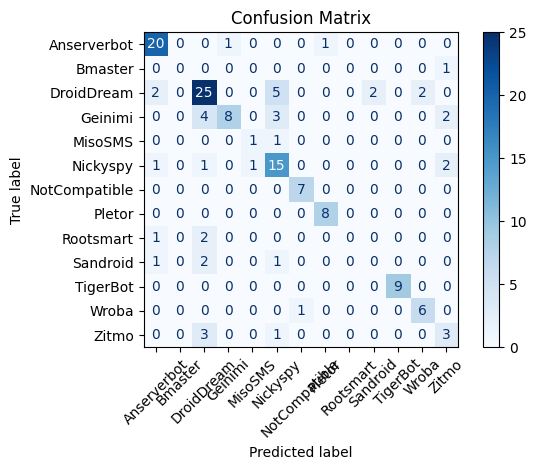

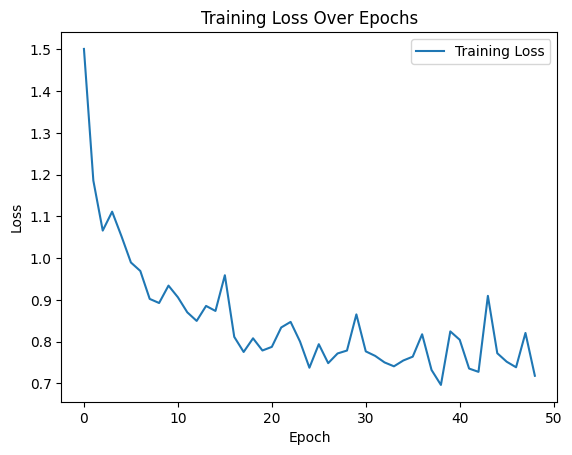

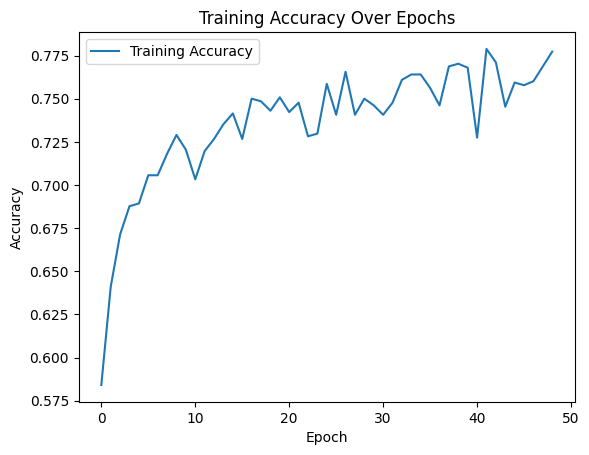

In [68]:
# Evaluate
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        pred = out.argmax(dim=1)
        y_true.extend(batch.y.cpu().tolist())
        y_pred.extend(pred.cpu().tolist())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=apk_dataset.labels))
plot_conf_matrix(y_true, y_pred, class_names=apk_dataset.labels)
plot_metrics(training_losses, training_accuracies)